<a href="https://colab.research.google.com/github/Dharshini13002/Digital-Image-Processing/blob/main/DIP_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) IMAGE TRANSFORM FOR WALSH, SLANT AND HADAMARD

In [8]:
from google.colab import files
uploaded = files.upload()
#image uploading

Saving sample1.jpeg to sample1.jpeg


In [9]:
#IMAGE LOADED
import cv2
image=cv2.imread('sample1.jpeg')
if image is None:
 print("failed to load iamge")
else:
 print("image loaded successfully!")

image loaded successfully!


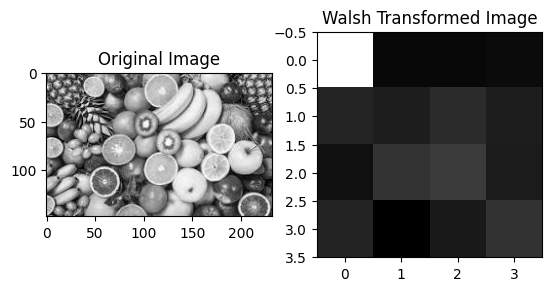

In [10]:
#WALSH TRANSFORMED IMAGE
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Load the image
image = cv2.imread('sample1.jpeg', cv2.IMREAD_GRAYSCALE)
# Define the Walsh matrix
def walsh_hadamard(n):

  if n == 1:
    return np.array([[1]])
  else:
    H = walsh_hadamard(n // 2)
    return np.block([[H, H], [H, -H]])
# Apply Walsh transform (using a 4x4 matrix for simplicity)
W = walsh_hadamard(4)
walsh_transformed = np.dot(np.dot(W, image[:4, :4]), W.T)
# Plot the original and transformed images
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(walsh_transformed, cmap='gray')
plt.title('Walsh Transformed Image')
plt.show()

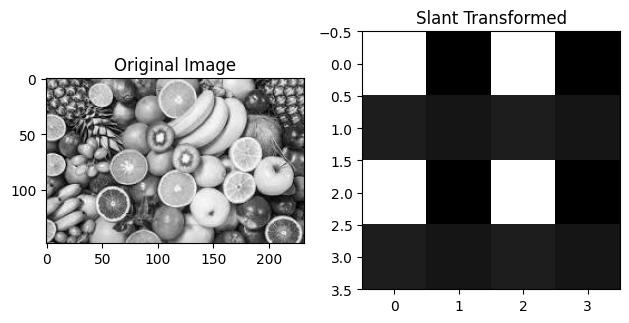

In [12]:
#SLANT TRANSFORMED IMAGE


import numpy as np
import cv2
import matplotlib.pyplot as plt


# Load the image
image = cv2.imread('sample1.jpeg', cv2.IMREAD_GRAYSCALE)


# Define the Slant matrix
def slant(n):
    S = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            S[i, j] = (-1) ** (i * j)
    return S


# Apply Slant transform (using a 4x4 matrix for simplicity)
S = slant(4)
slant_transformed = np.dot(np.dot(S, image[:4, :4]), S.T)
# Plot the original and transformed images
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(slant_transformed, cmap='gray')
plt.title('Slant Transformed')
plt.tight_layout()
plt.show()

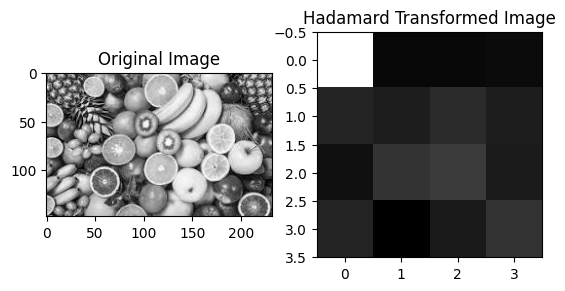

In [13]:
#HADAMARD TRANSFORMED IMAGE

import numpy as np
import cv2
import matplotlib.pyplot as plt
# Load the image
image = cv2.imread('sample1.jpeg', cv2.IMREAD_GRAYSCALE)
# Define the Hadamard matrix
def hadamard(n):
  if n == 1:
    return np.array([[1]])
  else:
    H = hadamard(n // 2)
    return np.block([[H, H], [H, -H]])
# Apply Hadamard transform (using a 4x4 matrix for simplicity)
H = hadamard(4)
hadamard_transformed = np.dot(np.dot(H, image[:4, :4]), H.T)
# Plot the original and transformed images
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(hadamard_transformed, cmap='gray')
plt.title('Hadamard Transformed Image')
plt.show()




2) FREQUENCY DOMAIN : SHARPENING AND SMOOTHING

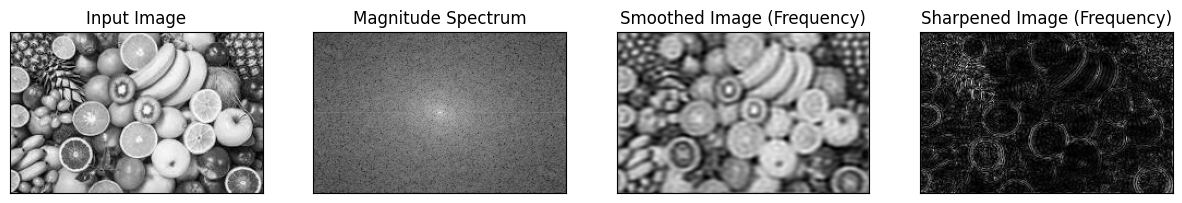

In [14]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
img = cv2.imread('sample1.jpeg', 0) # Load as grayscale

# Check if image loading was successful
if img is None:
    print("Error: Could not load image. Please make sure 'image.jpg' exists.")
else:
    # Apply Fourier Transform
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Create magnitude spectrum
    magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

    # --- Frequency Domain Smoothing (Low Pass Filter - Ideal) ---
    rows, cols = img.shape
    crow, ccol = int(rows/2), int(cols/2)

    # Create a mask
    mask_smooth = np.zeros((rows, cols, 2), np.uint8)
    r_smooth = 30 # Radius of the filter
    center = [crow, ccol]
    x, y = np.ogrid[:rows, :cols]
    mask_area = (x - center[0])**2 + (y - center[1])**2 <= r_smooth*r_smooth
    mask_smooth[mask_area] = 1

    # Apply mask and inverse DFT for smoothing
    fshift_smooth = dft_shift * mask_smooth
    f_ishift_smooth = np.fft.ifftshift(fshift_smooth)
    img_back_smooth = cv2.idft(f_ishift_smooth)
    img_back_smooth = cv2.magnitude(img_back_smooth[:,:,0], img_back_smooth[:,:,1])

    # --- Frequency Domain Sharpening (High Pass Filter - Ideal) ---
    # Create a high pass filter mask (inverse of the low pass mask)
    mask_sharp = 1 - mask_smooth

    # Apply mask and inverse DFT for sharpening
    fshift_sharp = dft_shift * mask_sharp
    f_ishift_sharp = np.fft.ifftshift(fshift_sharp)
    img_back_sharp = cv2.idft(f_ishift_sharp)
    img_back_sharp = cv2.magnitude(img_back_sharp[:,:,0], img_back_sharp[:,:,1])

    # --- Visualization ---
    plt.figure(figsize=(15, 5))

    plt.subplot(1,4,1),plt.imshow(img, cmap = 'gray')
    plt.title('Input Image'), plt.xticks([]), plt.yticks([])

    plt.subplot(1,4,2),plt.imshow(magnitude_spectrum, cmap = 'gray')
    plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])

    plt.subplot(1,4,3),plt.imshow(img_back_smooth, cmap = 'gray')
    plt.title('Smoothed Image (Frequency)'), plt.xticks([]), plt.yticks([])

    plt.subplot(1,4,4),plt.imshow(img_back_sharp, cmap = 'gray')
    plt.title('Sharpened Image (Frequency)'), plt.xticks([]), plt.yticks([])

    plt.show()